# 🏦 German Credit Risk — Random Forest

**Course: Finance & Machine Learning**

---

## 📌 What is Random Forest?

A **Random Forest** is an ensemble of many Decision Trees. Instead of relying on a single tree (which can overfit), it builds **hundreds of trees** on random subsets of data and features, then takes a **majority vote** for classification.

### Why use Random Forest for Credit Risk?
- Credit datasets are **imbalanced** (more good loans than bad)
- Credit decisions involve **complex, non-linear relationships** between features
- Random Forest handles **missing values, outliers, and mixed data types** well
- It provides **feature importance** — crucial for regulatory explainability in finance

### Key Advantages over a single Decision Tree:
| Feature | Decision Tree | Random Forest |
|---|---|---|
| Overfitting | High risk | Low risk |
| Stability | Low (sensitive to data) | High |
| Accuracy | Moderate | Higher |
| Interpretability | High | Moderate |
| Handles imbalance | Poor | Better (with `class_weight`) |

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Save/Load model
import joblib

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 2: Load the Dataset

We load the German Credit Risk dataset. 
- Each row represents a **loan applicant**.
- The target variable `Risk` tells us if the applicant was a **good** or **bad** credit risk.

In [2]:
df = pd.read_csv('data_german_credit.csv', index_col=0)
# df = pd.read_csv('https://raw.githubusercontent.com/ash322ash422/data/refs/heads/main/data_german_credit.csv', index_col=0)
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [3]:
# print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Dataset shape: {df.shape}") # rows, columns

Dataset shape: (1000, 10)


In [4]:
# First 5 rows:

print(df.head())


First 5 rows:
    Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own             NaN           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little              NaN           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  Risk  
0         6             radio/TV  good  
1        48             radio/TV   bad  
2        12            education  good  
3        42  furniture/equipment  good  
4        24                  car   bad  


In [5]:
# Quick summary of column types, etc

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB
None


In [6]:
print("\nNumeric Statistics:")
print(df.describe())


Numeric Statistics:
               Age          Job  Credit amount     Duration
count  1000.000000  1000.000000    1000.000000  1000.000000
mean     35.546000     1.904000    3271.258000    20.903000
std      11.375469     0.653614    2822.736876    12.058814
min      19.000000     0.000000     250.000000     4.000000
25%      27.000000     2.000000    1365.500000    12.000000
50%      33.000000     2.000000    2319.500000    18.000000
75%      42.000000     2.000000    3972.250000    24.000000
max      75.000000     3.000000   18424.000000    72.000000


In [6]:
print("\n Others Statistics:")
print(df.describe(include='object'))


 Others Statistics:
         Sex Housing Saving accounts Checking account Purpose  Risk
count   1000    1000             817              606    1000  1000
unique     2       3               4                3       8     2
top     male     own          little           little     car  good
freq     690     713             603              274     337   700


## Step 3: Exploratory Data Analysis (EDA)

Before building any model, we need to **understand the data**. In finance, this is called "Know Your Data" (KYD). We check:
- Class imbalance in the target
- Distribution of key features
- Missing values
- Correlations

In [7]:
target_counts = df['Risk'].value_counts()
target_counts

Risk
good    700
bad     300
Name: count, dtype: int64

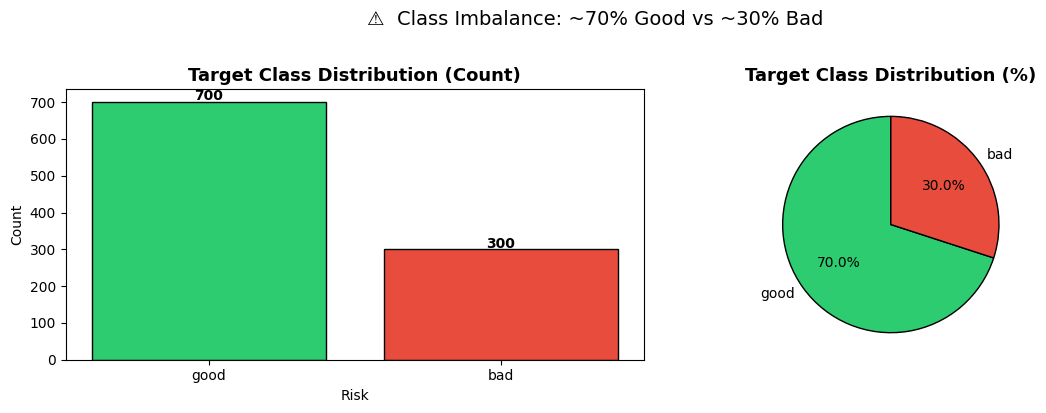


📌 NOTE: This 70/30 imbalance means a naive model that predicts 'good' every time
   would get 70% accuracy — but it would MISS all bad risks! We must address this.


In [8]:
# ── 3.1  Visualize target class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['Risk'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Target Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('⚠️  Class Imbalance: ~70% Good vs ~30% Bad', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 NOTE: This 70/30 imbalance means a naive model that predicts 'good' every time")
print("   would get 70% accuracy — but it would MISS all bad risks! We must address this.")

Missing Values Summary:
                  Missing Count  Missing %
Checking account            394       39.4
Saving accounts             183       18.3


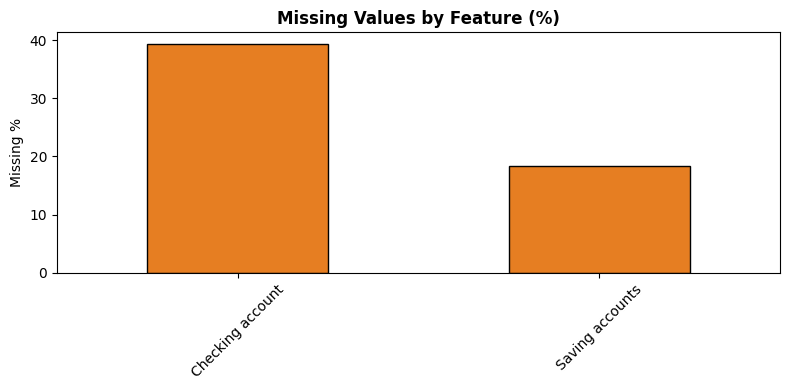

In [9]:
# ── 3.2  Missing values - Ideally these are handled after split into train + test
# To keep it simple, I am doing early.

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Missing Values Summary:")
print(missing_df)

# Visualise
if not missing_df.empty:
    missing_df['Missing %'].plot(kind='bar', color='#e67e22', figsize=(8, 4), edgecolor='black')
    plt.title('Missing Values by Feature (%)', fontweight='bold')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

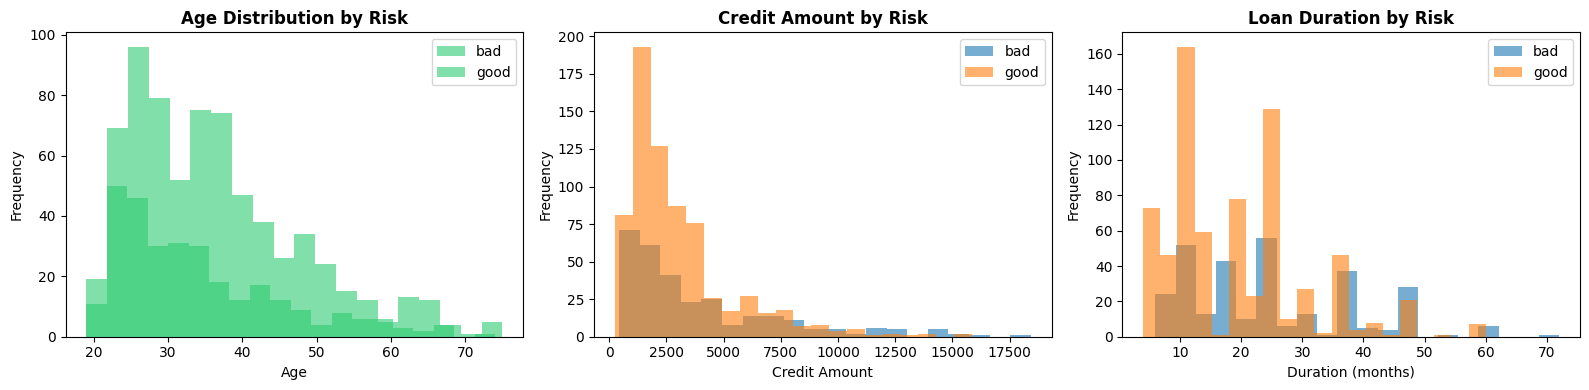

In [10]:
# ── 3.3  Age distribution by Risk
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age
df.groupby('Risk')['Age'].plot(kind='hist', bins=20, alpha=0.6, ax=axes[0],
                                legend=True, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Age Distribution by Risk', fontweight='bold')
axes[0].set_xlabel('Age')

# Credit Amount
df.groupby('Risk')['Credit amount'].plot(kind='hist', bins=20, alpha=0.6,
                                          ax=axes[1], legend=True)
axes[1].set_title('Credit Amount by Risk', fontweight='bold')
axes[1].set_xlabel('Credit Amount')

# Duration
df.groupby('Risk')['Duration'].plot(kind='hist', bins=20, alpha=0.6,
                                    ax=axes[2], legend=True)
axes[2].set_title('Loan Duration by Risk', fontweight='bold')
axes[2].set_xlabel('Duration (months)')

plt.tight_layout()
plt.show()

In [11]:
# ── 3.4  1) Categorical features vs Risk 

ct = pd.crosstab(df["Sex"], df['Risk'], normalize='index') * 100
ct

Risk,bad,good
Sex,,
female,35.161290,64.838710
male,27.681159,72.318841


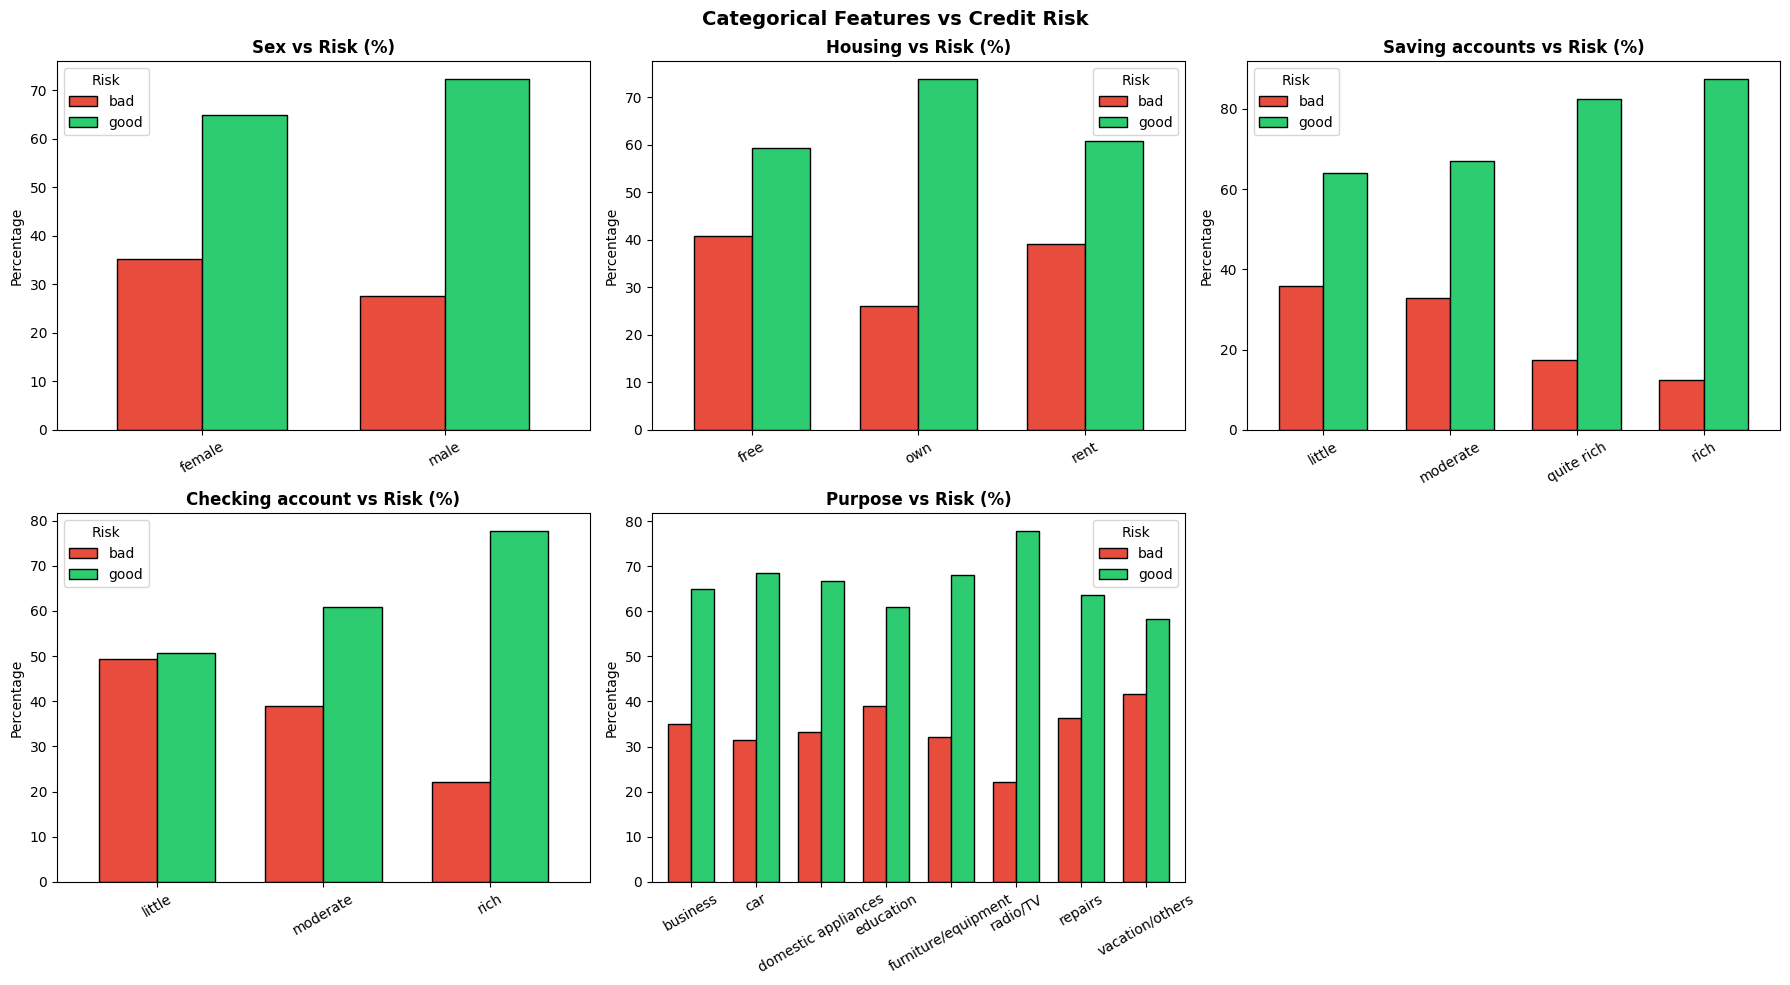

In [12]:
# ── 3.4  2) Categorical features vs Risk 
cat_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['Risk'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'],
            edgecolor='black', width=0.7)
    axes[i].set_title(f'{col} vs Risk (%)', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage')
    axes[i].legend(title='Risk')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].axis('off')  # hide unused subplot
plt.suptitle('Categorical Features vs Credit Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Preprocessing

Random Forest can handle many data types but **sklearn requires numerical inputs**. We need to:

1. **Encode categorical variables** using Label Encoding
2. **Handle missing values** — Random Forest can't handle NaN natively in sklearn; we impute with the **mode** (most frequent value) for categorical features
3. **Address class imbalance** using `class_weight='balanced'` inside the model (no need for SMOTE)

> 💡 **Finance Insight:** Label encoding is fine here since Random Forest splits on thresholds; it doesn't assume ordinality the way linear models do.

In [13]:
# ── 4.1  Copy and separate features / target 
data = df.copy()

# Encode target: good=1, bad=0
data['Risk'] = data['Risk'].map({'good': 1, 'bad': 0})
data

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,49,male,1,own,little,NaN,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,0
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,1
996,40,male,3,own,little,little,3857,30,car,1
997,38,male,2,own,little,NaN,804,12,radio/TV,1
998,23,male,2,free,little,little,1845,45,radio/TV,0


In [14]:
# ── 4.2  Impute missing values with mode (most frequent) 
# 'Saving accounts' and 'Checking account' have NAs — likely 'none/no account'
cat_cols = data.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}")

for col in cat_cols:
    mode_val = data[col].mode()[0]
    missing_count = data[col].isnull().sum()
    data[col].fillna(mode_val, inplace=True)
    if missing_count > 0:
        print(f"  → '{col}': filled {missing_count} NAs with mode = '{mode_val}'")



Categorical columns: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
  → 'Saving accounts': filled 183 NAs with mode = 'little'
  → 'Checking account': filled 394 NAs with mode = 'little'


In [15]:
data.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [16]:
# ── 4.3  Label encode all categorical columns
le = LabelEncoder()
encoding_map = {}  # store mapping for interpretability

for col in cat_cols:
    data[col] = le.fit_transform(data[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("\n Encoding complete. Mappings:")
for col, mapping in encoding_map.items():
    print(f"  {col}: {mapping}")


 Encoding complete. Mappings:
  Sex: {'female': 0, 'male': 1}
  Housing: {'free': 0, 'own': 1, 'rent': 2}
  Saving accounts: {'little': 0, 'moderate': 1, 'quite rich': 2, 'rich': 3}
  Checking account: {'little': 0, 'moderate': 1, 'rich': 2}
  Purpose: {'business': 0, 'car': 1, 'domestic appliances': 2, 'education': 3, 'furniture/equipment': 4, 'radio/TV': 5, 'repairs': 6, 'vacation/others': 7}


correlation matrix:
                        Age       Sex       Job   Housing  Saving accounts  \
Age               1.000000  0.161694  0.015673 -0.301419         0.015772   
Sex               0.161694  1.000000  0.070298 -0.219844        -0.014425   
Job               0.015673  0.070298  1.000000 -0.107191        -0.034596   
Housing          -0.301419 -0.219844 -0.107191  1.000000         0.043324   
Saving accounts   0.015772 -0.014425 -0.034596  0.043324         1.000000   
Checking account -0.027176 -0.012705 -0.043277 -0.028196         0.015763   
Credit amount     0.032716  0.093482  0.285385 -0.135632        -0.077929   
Duration         -0.036136  0.081432  0.210910 -0.157049        -0.043274   
Purpose          -0.074084 -0.063231 -0.025326  0.020633        -0.024817   
Risk              0.091127  0.075493 -0.032735 -0.019315         0.102751   

                  Checking account  Credit amount  Duration   Purpose  \
Age                      -0.027176       0.032716 -0.03613

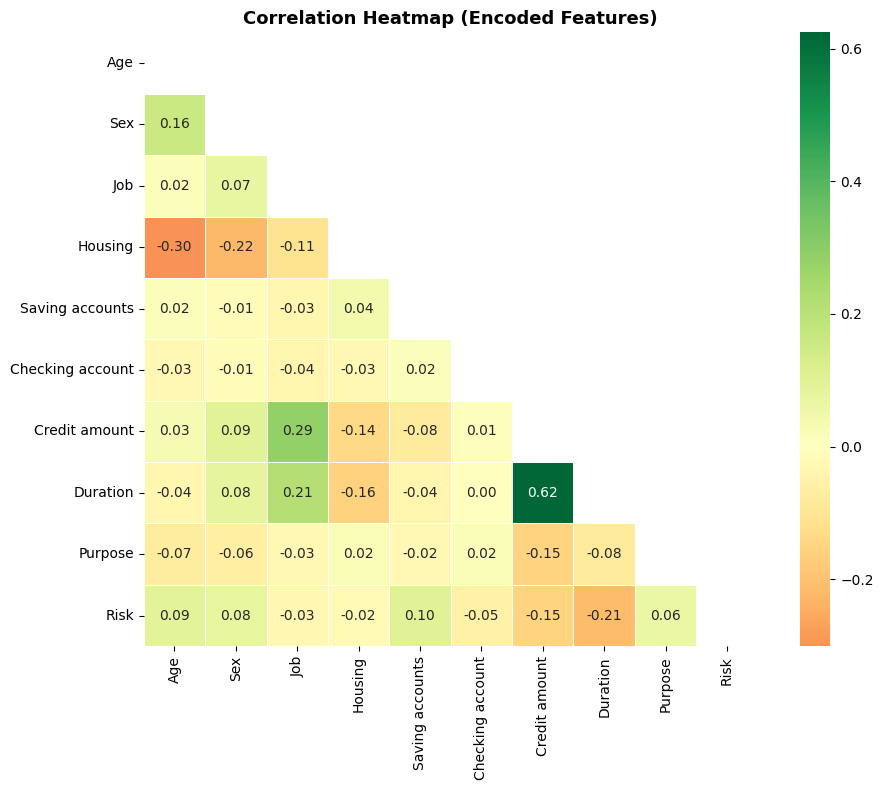


📌 Note: Random Forest does NOT require uncorrelated features (unlike linear models).
   High correlation between features is not a problem here.


In [13]:
# ── 4.4  Correlation heatmap (after encoding)
plt.figure(figsize=(10, 8))
corr = data.corr()
print("correlation matrix:\n",corr,"\n")

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap (Encoded Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n📌 Note: Random Forest does NOT require uncorrelated features (unlike linear models).")
print("   High correlation between features is not a problem here.")

In [17]:
# ── 4.5  Train-test split 
X = data.drop('Risk', axis=1)
y = data['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, 
    stratify=y  # stratify preserves 70/30 split
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).rename({1: 'good', 0: 'bad'}).apply(lambda x: f"{x:.1%}"))

Training set:  800 samples
Test set:      200 samples

Class balance in training set:
Risk
good    70.0%
bad     30.0%
Name: proportion, dtype: object


## Step 5: Train the Random Forest

### Key Hyperparameters to understand:

| Parameter | What it controls | Our choice |
|---|---|---|
| `n_estimators` | Number of trees in the forest | 200 |
| `max_depth` | How deep each tree can grow | None (full) |
| `max_features` | Features considered at each split | `'sqrt'` |
| `class_weight` | Penalise misclassifying minority class | `'balanced'` |
| `random_state` | Reproducibility | 42 |

> 💡 **`class_weight='balanced'`** is our fix for the 70/30 imbalance. It automatically weights bad-risk samples ~2.3× more heavily, so the model pays equal *attention* to both classes.

In [18]:
# ── 5.1  Train Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=200,          # 200 decision trees in the ensemble
    max_features='sqrt',       # sqrt(n_features) features considered per split — reduces correlation between trees
    class_weight='balanced',   # ← KEY: handles the 70/30 imbalance automatically
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)

rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")
print(f"   Number of trees: {rf_model.n_estimators}")
print(f"   Number of features: {rf_model.n_features_in_}")

Random Forest trained successfully!
   Number of trees: 200
   Number of features: 9


feature_importance:
             Feature  Importance
1               Sex    0.032913
3           Housing    0.044831
5  Checking account    0.045936
4   Saving accounts    0.047025
2               Job    0.057612
8           Purpose    0.096604
7          Duration    0.177227
0               Age    0.209685
6     Credit amount    0.288167


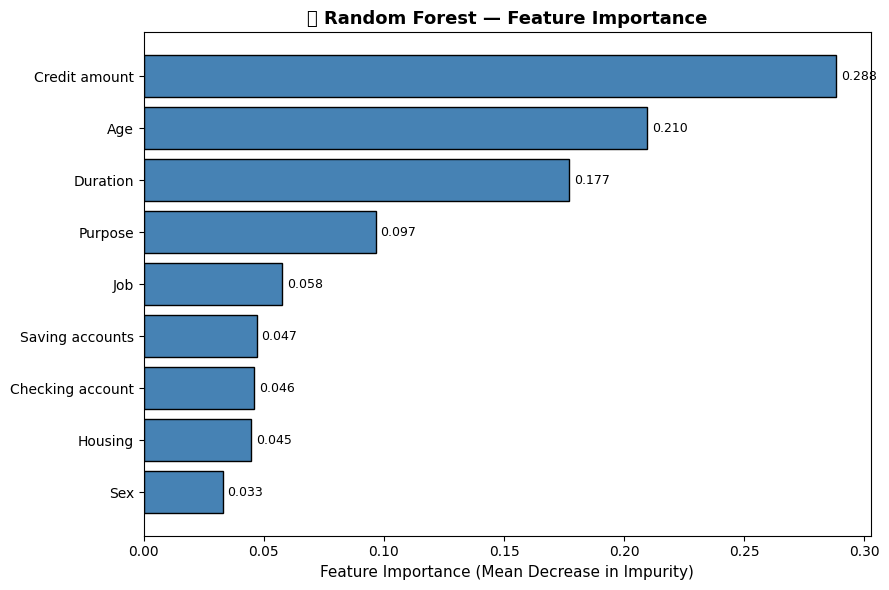


📌 Finance Insight: Feature importance helps satisfy regulatory explainability
   requirements (e.g., Basel III, GDPR 'right to explanation').


In [19]:
# ── 5.2  Feature Importance — the 'why' behind predictions 
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

print("feature_importance:\n", feature_importance)


plt.figure(figsize=(9, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'],
                color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
plt.title('🌳 Random Forest — Feature Importance', fontweight='bold', fontsize=13)

for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📌 Finance Insight: Feature importance helps satisfy regulatory explainability")
print("   requirements (e.g., Basel III, GDPR 'right to explanation').")

## Step 6: Test on 1 Sample

Let's simulate what happens when a **new loan applicant** comes in. We pass their data through the model and get a prediction with probability.

In [20]:
# ── 6.1  Pick one sample from the test set ────────────────────────────────────
sample_idx = 0
sample = X_test.iloc[[sample_idx]]   # double brackets keep it as a DataFrame
actual_label = y_test.iloc[sample_idx]

# Predict
prediction = rf_model.predict(sample)[0]
probabilities = rf_model.predict_proba(sample)[0]

label_map = {1: 'GOOD ✅', 0: 'BAD ❌'}

print("=" * 50)
print("        LOAN APPLICATION DECISION")
print("=" * 50)
print(f"\nApplicant features:")
print(sample.to_string())
print(f"\nModel Prediction  : {label_map[prediction]}")
print(f"Actual Label      : {label_map[actual_label]}")
print(f"\nProbability of BAD  risk : {probabilities[0]:.1%}")
print(f"Probability of GOOD risk : {probabilities[1]:.1%}")
print("=" * 50)

if prediction == actual_label:
    print("\n🎯 Prediction is CORRECT!")
else:
    print("\n❌ Prediction is WRONG — this is the cost of Type I / Type II error in credit risk.")

        LOAN APPLICATION DECISION

Applicant features:
     Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  Duration  Purpose
977   42    1    2        1                0                 1           2427        18        0

Model Prediction  : GOOD ✅
Actual Label      : GOOD ✅

Probability of BAD  risk : 16.0%
Probability of GOOD risk : 84.0%

🎯 Prediction is CORRECT!


## Step 7: Model Evaluation

In **credit risk**, the cost of errors is asymmetric:
- **False Negative (predicting 'good' when actually 'bad')** → Bank loses money on a defaulting loan 💸
- **False Positive (predicting 'bad' when actually 'good')** → Bank loses business opportunity

We use multiple metrics:
- **Precision / Recall / F1**: Better than accuracy for imbalanced data
- **ROC-AUC**: Measures overall discriminating power (closer to 1 = better)
- **Confusion Matrix**: Shows exact breakdown of prediction errors

In [21]:
# ── 7.1  Predictions on full test set ─────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Also compare with a single Decision Tree (to show RF advantage)
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  RANDOM FOREST — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=['Bad (0)', 'Good (1)']))

print("=" * 55)
print("  DECISION TREE — Classification Report (for comparison)")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, target_names=['Bad (0)', 'Good (1)']))

  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

     Bad (0)       0.59      0.32      0.41        60
    Good (1)       0.76      0.91      0.82       140

    accuracy                           0.73       200
   macro avg       0.67      0.61      0.62       200
weighted avg       0.71      0.73      0.70       200

  DECISION TREE — Classification Report (for comparison)
              precision    recall  f1-score   support

     Bad (0)       0.36      0.35      0.35        60
    Good (1)       0.72      0.73      0.73       140

    accuracy                           0.61       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.61      0.61      0.61       200



confusion  matrix for random forest:
 [[ 19  41]
 [ 13 127]]
confusion  matrix for random forest(Normalized):
 [[32. 68.]
 [ 9. 91.]]


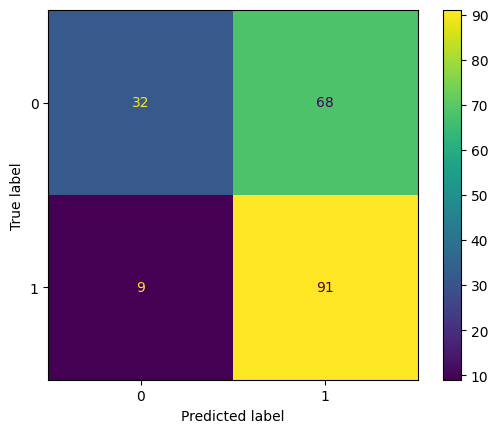

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)
print("confusion  matrix for random forest:\n", cm)


# 'true' normalizes over the true labels (rows)
cm_normalized = confusion_matrix(y_test, y_pred_rf, normalize='true').round(2) * 100
print("confusion  matrix for random forest(Normalized):\n", cm_normalized)


disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized)
disp.plot()
# plt.show()

# Interpretation
Looking at these results through a **credit risk lens** — here's what the numbers actually mean for a bank.

---

## 🏦 The Core Problem: Bad Loans Are Being Missed

The confusion matrix tells the real story. For every **100 actual bad-risk applicants**, the Random Forest:
- Correctly rejects only **32** of them ✅
- **Approves 68 of them** as if they were good risk ❌ ← This is the bank's financial loss

For every **100 actual good-risk applicants**, the model:
- Correctly approves **91** of them ✅
- Wrongly rejects only **9** ❌ ← Lost business, but no financial loss

---

## 📊 Metric-by-Metric Breakdown

### Random Forest vs Decision Tree

| Metric | RF — Bad (0) | RF — Good (1) | DT — Bad (0) | DT — Good (1) |
|---|---|---|---|---|
| Precision | 0.59 | 0.76 | 0.36 | 0.72 |
| Recall | **0.32** | 0.91 | 0.35 | 0.73 |
| F1-Score | 0.41 | 0.82 | 0.35 | 0.73 |

**Precision (Bad class = 0.59 for RF):** When the model *does* flag someone as bad risk, it is right 59% of the time. That's decent — rejections are more accurate than random. The Decision Tree is only right 36% of the time — barely better than a coin flip.

**Recall (Bad class = 0.32 for RF):** This is the critical number. The model only catches 32% of actual bad borrowers. This means **68 out of every 100 bad loans get approved**. In a real bank portfolio, this would translate directly to Non-Performing Loans (NPLs).

**F1-Score (Bad class = 0.41 for RF):** The harmonic mean of precision and recall. Anything below 0.5 on the minority class is a signal that the model is struggling with bad-risk detection — despite `class_weight='balanced'`.

---

## 🔍 Why Is Bad-Recall So Low?

Three likely causes:

**1. The 70/30 imbalance is still dominating.** Even with `class_weight='balanced'`, the model has seen far more "good" examples and has learned more confident patterns for that class. The 32% recall on bad risk means the signal for default is genuinely weak in this dataset.

**2. The dataset is small.** With only 1,000 rows (200 in test), you have just 60 bad-risk test cases. Statistical noise is high — even one or two wrong splits in the trees affect recall significantly.

**3. The default 0.5 decision threshold is wrong for this problem.** The model outputs a probability, and we call someone "bad risk" only if P(bad) > 0.5. But in credit risk, you might want to flag anyone with P(bad) > 0.3 as bad. This threshold controls the precision-recall tradeoff.

---

## ⚖️ The Business Tradeoff

This is the fundamental tension in credit risk modeling:

```
Raise the bad-risk threshold  →  Catch more bad loans (higher recall)
                                  but reject more good customers (lower precision)

Lower the bad-risk threshold  →  Approve more good customers (good business)
                                  but miss more bad loans (financial loss)
```

The right threshold depends on the **cost ratio**: how much does one bad loan cost vs. how much profit does one good loan generate?

This is a business decision, not a model decision.

---

## ✅ What RF Does Well vs Decision Tree

RF is clearly better across every metric:

- **Overall accuracy**: 73% vs 61% — a 12-point improvement
- **Bad-risk precision**: 0.59 vs 0.36 — RF's rejections are nearly twice as trustworthy
- **Good-risk recall**: 0.91 vs 0.73 — RF approves 18% more legitimate customers
- **Macro F1**: 0.62 vs 0.54 — RF is more balanced across both classes

The Decision Tree is essentially unreliable for the bad class (precision 0.36, recall 0.35 — barely better than random). This is the overfitting problem of single trees in action.


## 📌 The One Number That Matters to a Risk Manager

**68% of bad loans are being approved.** Everything else is context around that number. A risk manager's job is to decide whether that is acceptable, and if not, what precision-recall tradeoff they are willing to accept to reduce it.

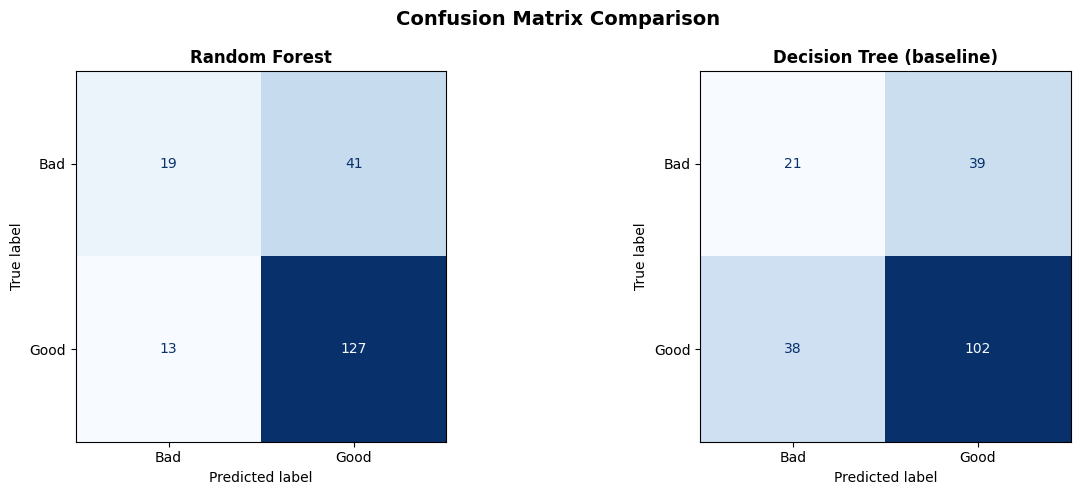

In [20]:
# ── 7.2  Confusion matrices side-by-side 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_dt],
    ['Random Forest', 'Decision Tree (baseline)']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Bad', 'Good'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


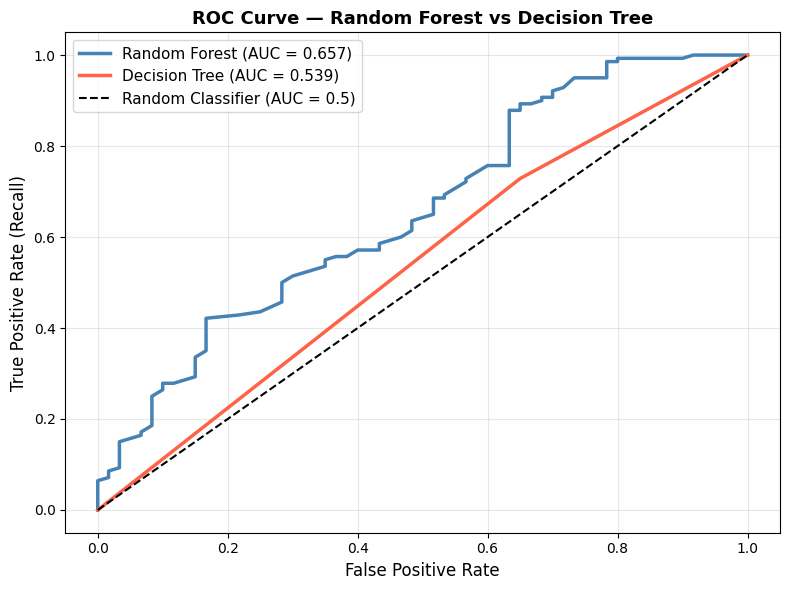


🏆 AUC Score — Random Forest : 0.6573
   AUC Score — Decision Tree : 0.5393
   Improvement               : +0.1180

📌 AUC > 0.7 is generally considered acceptable in credit scoring (Basel III standard).


In [21]:
# ── 7.3  ROC Curves 
plt.figure(figsize=(8, 6))

for y_prob, label, color in [
    (y_prob_rf, 'Random Forest', 'steelblue'),
    (y_prob_dt, 'Decision Tree', 'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{label} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — Random Forest vs Decision Tree', fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rf_auc = roc_auc_score(y_test, y_prob_rf)
dt_auc = roc_auc_score(y_test, y_prob_dt)
print(f"\n🏆 AUC Score — Random Forest : {rf_auc:.4f}")
print(f"   AUC Score — Decision Tree : {dt_auc:.4f}")
print(f"   Improvement               : +{(rf_auc - dt_auc):.4f}")
print("\n📌 AUC > 0.7 is generally considered acceptable in credit scoring (Basel III standard).")

## AUC of 0.65 is mediocre

# (OPTIONAL)

## Step 8: Save and Load the Model

In production banking systems, models are **saved and versioned** so that:
- The same model is used consistently for all decisions
- Models can be **audited** and **rolled back** if needed
- Regulators can inspect the exact model used on any given date

We use `joblib` — the standard tool for saving sklearn models.

In [22]:
# ── 8.1  Save the model 
model_path = 'rf_credit_risk_model.joblib'
joblib.dump(rf_model, model_path)
print(f"✅ Model saved to: {model_path}")

# ── 8.2  Load the model back 
loaded_model = joblib.load(model_path)
print(f"✅ Model loaded successfully!")

# ── 8.3  Verify loaded model gives same predictions
loaded_pred = loaded_model.predict(X_test)
assert (loaded_pred == y_pred_rf).all(), "❌ Loaded model gives different predictions!"
print("✅ Verification passed: loaded model matches original model predictions exactly.")

✅ Model saved to: rf_credit_risk_model.joblib
✅ Model loaded successfully!
✅ Verification passed: loaded model matches original model predictions exactly.


## Step 9: Using the Loaded Model on a New Applicant

This simulates how a bank's loan officer would use the model in real life.

In [23]:
# ── New applicant (manually entered data) ─
# Create a new applicant using the encoded values from encoding_map above
# For reference: Sex {'female':0,'male':1}, Housing {'free':0,'own':1,'rent':2},
# Saving accounts {'little':0,'moderate':1,'NA(none)':2,'quite rich':3,'rich':4}
# Checking account {'little':0,'moderate':1,'NA(none)':2,'rich':3}

new_applicant = pd.DataFrame([{
    'Age': 34,
    'Sex': 1,                   # male
    'Job': 2,
    'Housing': 1,               # own
    'Saving accounts': 0,       # little
    'Checking account': 2,      # none/NA
    'Credit amount': 8500,
    'Duration': 36,
    'Purpose': encoding_map['Purpose'].get('car', 0)
}])

pred = loaded_model.predict(new_applicant)[0]
prob = loaded_model.predict_proba(new_applicant)[0]

print("🏦 LOAN DECISION SYSTEM (using saved model)")
print("=" * 45)
print(f"  Prediction       : {'APPROVED ✅' if pred == 1 else 'REJECTED ❌'}")
print(f"  P(Good risk)     : {prob[1]:.1%}")
print(f"  P(Bad  risk)     : {prob[0]:.1%}")
print("=" * 45)

🏦 LOAN DECISION SYSTEM (using saved model)
  Prediction       : APPROVED ✅
  P(Good risk)     : 83.0%
  P(Bad  risk)     : 17.0%


## 📚 Summary

| Topic | Key Takeaway |
|---|---|
| **Class Imbalance** | Use `class_weight='balanced'` — never ignore it in finance |
| **Random Forest vs Decision Tree** | RF is more stable, less prone to overfitting |
| **Feature Importance** | Credit amount, duration, and age drive risk most |
| **AUC over Accuracy** | Always use AUC for imbalanced credit data |
| **Model Saving** | Essential for audit trails and regulatory compliance |
| **Probability scores** | More useful than binary yes/no — allows risk tiering |
